In [37]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [38]:
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

from sklearn.metrics import f1_score
import src.utils as utils
from src.model import MetMulDagma, MetMulColide

from baselines.colide import colide_ev, colide_nv
from baselines.dagma_linear import DAGMA_linear
from baselines.golem import GOLEM_EV, GOLEM_NV
from baselines.nofears import NoFearsLinear
from baselines.nonnegative_dagma_linear import NonnegativeDAGMA_linear
from baselines.notears import notears_linear
from baselines.sortnregress import VarSortNRegress

FILE_PATH = "./datasets/sachs/"

## Auxiliary functions

In [39]:
def get_lamb_value(n_nodes, n_samples, times=1):
    return np.sqrt(np.log(n_nodes) / n_samples) * times 

def compute_errsW(W_seq, W_true):
    errs = np.zeros(len(W_seq))
    norm_W_true = np.linalg.norm(W_true)
    for i, W_est in enumerate(W_seq):
        errs[i] = (np.linalg.norm(W_true - W_est)/norm_W_true)**2
    
    return errs

def plot_convergence(model, W_true, leg=''):
    errs_W = compute_errsW(model.seq_W, W_true)
    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1)
    plt.semilogy(model.diff_W)
    plt.title(leg + ' - Convergence of W')
    plt.subplot(1,3,2)
    plt.semilogy(errs_W)
    plt.title(leg + ' - Error')
    plt.subplot(1,3,3)
    plt.semilogy(model.acyclicity)
    plt.title(leg + ' - Acyclicity')
    plt.tight_layout()

def run_exp(exps, W_true, X, X_std, n_nodes, n_samples, plot_conv=False):
    Ws_est = np.zeros((len(exps), n_nodes, n_nodes))
    times = np.zeros(len(exps))
    for i, exp in enumerate(exps):
        X_aux = X_std if 'standarize' in exp.keys() and exp['standarize'] else X

        arg_aux = exp['args'].copy()
        if exp.get('adapt_lamb', False):
            if 'lamb' in arg_aux:
                arg_aux['lamb'] = get_lamb_value(n_nodes, n_samples, arg_aux['lamb'])
            elif 'lambda1' in arg_aux:
                arg_aux['lambda1'] = get_lamb_value(n_nodes, n_samples, arg_aux['lambda1'])

        if exp['model'] == MetMulDagma:
            arg_aux['track_seq'] = plot_conv


        t_init = perf_counter()
        if exp['model'] == notears_linear:
            model = None
            W_est = notears_linear(X_aux.copy(), **arg_aux)
        else:
            model = exp['model'](**exp['init']) if 'init' in exp.keys() else exp['model']()
            model.fit(X_aux.copy(), **arg_aux)
            W_est = model.W_est
        t_end = perf_counter()

        if np.isnan(W_est).any():
            W_est = np.zeros_like(W_est)

        Ws_est[i] = W_est
        times[i] = t_end - t_init

        if plot_conv and exp['model'] == MetMulDagma:
            plot_convergence(model, W_true, exp['leg'])
    
    return Ws_est, times

def plot_dag_and_adj(dag, A, labels=None):
    # Plot gaph and adjacency with only strong edges
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    pos = nx.circular_layout(dag)
    nx.draw(dag, pos, with_labels=True, node_size=500, node_color='lightblue', arrowsize=15, ax=ax1)
    ax1.set_title("DAG")
    ax1.axis("off")

    im = ax2.imshow(A, cmap='Blues', interpolation='none')
    fig.colorbar(im, ax=ax2, label='Edge weight')

    if labels is not None:
        ax2.set_xticks(np.arange(len(labels)))
        ax2.set_yticks(np.arange(len(labels)))
        ax2.set_xticklabels(labels, rotation=90)
        ax2.set_yticklabels(labels)
    
    ax2.set_title("Adjacency (strong edges)")
    ax2.set_xlabel("Destiny")
    ax2.set_ylabel("Source")
    plt.tight_layout()
    plt.show()

def _draw_graph_pdf(
    adjacency, labels, positions, output_path, show=True, edge_rad=0,
):
    graph = nx.from_numpy_array(
        (np.asarray(adjacency) != 0).astype(int),
        create_using=nx.DiGraph,
    )
    graph = nx.relabel_nodes(graph, dict(enumerate(labels)))

    fig, ax = plt.subplots(figsize=(7.2, 7.2))
    node_size = 1900
    nx.draw_networkx_nodes(
        graph, positions, ax=ax, node_size=node_size,
        node_color='#b9dfea', edgecolors='#315d6b', linewidths=1.5,
    )
    nx.draw_networkx_edges(
        graph, positions, ax=ax, arrows=True, arrowstyle='-|>',
        arrowsize=26, width=1.8, edge_color='#202020',
        node_size=node_size, connectionstyle=f'arc3,rad={edge_rad}',
        min_source_margin=16, min_target_margin=20,
    )
    nx.draw_networkx_labels(
        graph, positions, ax=ax, font_size=17, font_weight='semibold',
        font_family='sans-serif',
    )

    # Fix the limits so that the larger layout radius is preserved on export.
    extent = max(np.max(np.abs(position)) for position in positions.values()) + .32
    ax.set_xlim(-extent, extent)
    ax.set_ylim(-extent, extent)
    ax.set_aspect('equal')
    ax.set_axis_off()
    fig.tight_layout(pad=.1)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=.04)
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_selected_graphs(
    methods, exps, Ws_est, W_true, labels, output_dir,
    default_threshold=.3, thresholds=None, show=True,
):
    thresholds = {} if thresholds is None else thresholds
    labels = list(labels)
    positions = nx.circular_layout(labels, scale=1.8)
    exp_indices = {exp['leg']: index for index, exp in enumerate(exps)}
    saved_paths = {}

    for method in methods:
        if method == 'Original':
            adjacency = utils.to_bin(W_true, default_threshold)
            filename = 'G_true.pdf'
            edge_rad = 0
        else:
            if method not in exp_indices:
                raise KeyError(f'Unknown method requested for plotting: {method}')
            index = exp_indices[method]
            exp = exps[index]
            model_threshold = thresholds.get(method, default_threshold)
            W_plot = Ws_est[index].copy()
            if exp.get('to_dag', False):
                W_plot = utils.to_dag(W_plot, model_threshold)
            adjacency = utils.to_bin(W_plot, model_threshold)
            filename = f"G_est_{method.replace('-', '_')}.pdf"
            edge_rad = 0

        output_path = Path(output_dir) / filename
        _draw_graph_pdf(
            adjacency, labels, positions, output_path, show=show,
            edge_rad=edge_rad,
        )
        saved_paths[method] = output_path
        print(f'{method}: {output_path}')

    return saved_paths


def display_results_table(results, thr=None, caption='Results'):
    numeric_format = {
        'SHD': '{:.0f}', 'TPR': '{:.3f}', 'FDR': '{:.3f}', 'F1': '{:.3f}',
        'SID': '{:.3f}', 'Error': '{:.3f}', 'Time (s)': '{:.2f}',
        'Threshold': '{:.2f}',
    }
    table_styles = [
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ]
    threshold_suffix = f' · threshold={thr:g}' if thr is not None else ''
    styled = (
        results.style
        .format(numeric_format, na_rep='—')
        .set_caption(f'{caption}{threshold_suffix}')
        .set_table_styles(table_styles)
        .highlight_min(subset=['SHD', 'Error', 'Time (s)'], props='font-weight: bold;')
        .highlight_max(subset=['TPR', 'F1'], props='font-weight: bold;')
    )
    display(styled)

def plot_results(exps, Ws_est, W_true, running_times, thr=.3, plot=False, thresholds=None):
    thresholds = {} if thresholds is None else thresholds
    norm_W_true = np.linalg.norm(W_true)
    rows = []

    for i, exp in enumerate(exps):
        model_thr = thresholds.get(exp['leg'], thr)
        W_true_bin = utils.to_bin(W_true, model_thr)
        W_est = Ws_est[i]
        if exp.get('to_dag', False):
            W_est = utils.to_dag(W_est, model_thr)
        W_est_bin = utils.to_bin(W_est, model_thr)
        shd, tpr, fdr = utils.count_accuracy(W_true_bin, W_est_bin)
        fscore = f1_score(W_true_bin.flatten(), W_est_bin.flatten())
        err = utils.compute_norm_sq_err(W_true, W_est, norm_W_true)
        sid = utils.sid(W_true_bin, W_est_bin, normalize=True) if utils.is_dag(W_est_bin) else np.nan
        rows.append({
            'Method': exp['leg'],
            'Standardized': exp.get('standarize', False),
            'Threshold': model_thr,
            'SHD': shd,
            'TPR': tpr,
            'FDR': fdr,
            'F1': fscore,
            'SID': sid,
            'Error': err,
            'Time (s)': running_times[i],
        })

        if plot:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            im1 = ax1.imshow(W_true, cmap='Blues', interpolation='none')
            ax1.set_title("W true")
            fig.colorbar(im1, ax=ax1)
            im2 = ax2.imshow(W_est, cmap='Blues', interpolation='none')
            ax2.set_title("W_est - " + exp['leg'])
            fig.colorbar(im2, ax=ax2)
            plt.tight_layout()

    results = pd.DataFrame(rows)
    used_thresholds = results['Threshold'].unique()
    table_thr = used_thresholds[0] if len(used_thresholds) == 1 else None
    caption = 'Results' if table_thr is not None else 'Results · per-model thresholds'
    display_results_table(results, table_thr, caption=caption)

    return results

## Load and plot data

11 nodes, 853 samples
2.2580974682540975
0.010000000000000002


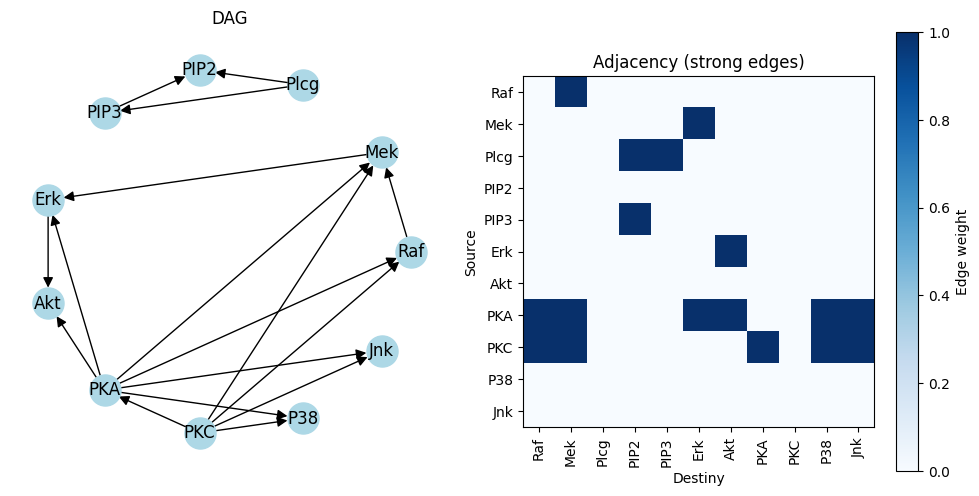

In [40]:
X = np.array(
    np.load(FILE_PATH + "sachs_X.npy"),
    dtype=float,
    copy=True,
    order="C",
)
node_order = np.load(FILE_PATH + "node_order.npy")
W = np.load(FILE_PATH + "sachs_A_matrix.npy")
W_all = np.load(FILE_PATH + "sachs_A_matrix_all.npy")

expected_node_order = [
    "Raf", "Mek", "Plcg", "PIP2", "PIP3",
    "Erk", "Akt", "PKA", "PKC", "P38", "Jnk",
]
assert node_order.tolist() == expected_node_order, (
    f"Unexpected Sachs node order: {node_order.tolist()}"
)
assert X.shape[1] == len(node_order)
assert W.shape == (len(node_order), len(node_order))
idx = {name: i for i, name in enumerate(node_order)}
assert W[idx["Raf"], idx["Mek"]] == 1
assert W[idx["Mek"], idx["Raf"]] == 0
assert W.sum() == 17
assert nx.is_directed_acyclic_graph(nx.DiGraph(W))

X_std = utils.standarize(X)

n_samples, n_nodes = X.shape

print(f"{n_nodes} nodes, {n_samples} samples")

print(np.linalg.norm(X)/np.sqrt(n_samples * n_nodes)*.01)
print(np.linalg.norm(X_std)/np.sqrt(n_samples * n_nodes)*.01)

dag = nx.DiGraph(W)
dag = nx.relabel_nodes(dag, dict(enumerate(node_order)))

plot_dag_and_adj(dag, W, labels=node_order)


In [41]:
thr = .3
plot_W = False
plot_conv = False

Exps = [
### Best settings NOMAD
{'model': MetMulDagma, 'args': {'stepsize': 1e-4, 'alpha_0': 2, 'rho_0': .01, 's': .7, 'lamb': .005,
 'iters_in': 5000, 'iters_out': 5, 'beta': 2, 'Sigma': 1}, 'init': {'primal_opt': 'adam', 'acyclicity': 'logdet', 'restart': True},
 'adapt_lamb': True, 'standarize': True, 'fmt': 'o-', 'leg': 'NOMAD-adam'},

# FISTA, raw data, fixed step: best SHD (SHD=11, err=1.181357694).
{'model': MetMulDagma, 'args': {'stepsize': 5e-5, 'alpha_0': .5, 'rho_0': .01, 'beta': 5, 's': 1.1,
 'lamb': .01, 'iters_in': 5000, 'iters_out': 50, 'Sigma': 1, 'tol': 1e-6, 'h_tol': 1e-4, 'step_type': 'fixed'},
 'init': {'primal_opt': 'fista', 'acyclicity': 'logdet', 'restart': True}, 'adapt_lamb': True, 'standarize': False,
 'fmt': 'o-', 'leg': 'NOMAD-fista'},

### Baselines
# # NOTEARS restores max_iter=100 (official default; preliminaries used 10).
# {'model': notears_linear, 'args': {'loss_type': 'l2', 'lambda1': .1, 'max_iter': 100},
#  'standarize': False, 'fmt': 'x--', 'leg': 'NoTears'},

# {'model': NoFearsLinear, 'args': {'lambda1': .1, 'w_threshold': .3, 'max_iter': 100, 'h_tol': 1e-10,
#  'rho_init': 1., 'rho_factor': 10., 'rho_max': 1e16, 'h_progress_rate': .25, 'w_tol': 1e-10,
#  'pen_tol': 0., 'rev_edges': 'alt-full', 'minimize_z': True, 'init_no_pen': True, 'no_pen': False},
#  'standarize': False, 'fmt': 'P--', 'leg': 'NoFears'},

{'model': DAGMA_linear, 'init': {'loss_type': 'l2'},
 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7], 'warm_iter': 2e4,
 'max_iter': 7e4, 'lr': .0003}, 'to_dag': True, 'standarize': False, 'fmt': '^-', 'leg': 'DAGMA'},

{'model': DAGMA_linear, 'init': {'loss_type': 'l2'},
 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7], 'warm_iter': 2e4,
 'max_iter': 7e4, 'lr': .0003}, 'to_dag': True, 'standarize': True, 'fmt': '^-', 'leg': 'DAGMA-std'},

{'model': NonnegativeDAGMA_linear, 'init': {'loss_type': 'l2'},
 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7], 'warm_iter': 2e4,
 'max_iter': 7e4, 'lr': .0003}, 'to_dag': True, 'standarize': False, 'fmt': 'd--', 'leg': 'NonDAGMA'},

{'model': colide_ev, 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7],
 'warm_iter': 2e4, 'max_iter': 7e4, 'lr': .0003},
 'standarize': False, 'fmt': 'v--', 'leg': 'CoLiDE-EV'},

{'model': colide_nv, 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7],
 'warm_iter': 2e4, 'max_iter': 7e4, 'lr': .0003},
 'standarize': False, 'fmt': 's--', 'leg': 'CoLiDE-NV'},

{'model': GOLEM_EV, 'args': {'lambda1': 2e-2, 'lambda2': 5.0, 'num_iter': 100000,
 'learning_rate': 1e-3, 'w_threshold': .3, 'postprocess': True, 'checkpoint': None},
 'standarize': False, 'fmt': '<--', 'leg': 'GOLEM-EV'},

{'model': GOLEM_EV, 'args': {'lambda1': 2e-2, 'lambda2': 5.0, 'num_iter': 100000,
 'learning_rate': 1e-3, 'w_threshold': .3, 'postprocess': True, 'checkpoint': None},
 'standarize': True, 'fmt': '<--', 'leg': 'GOLEM-EV-std'},

{'model': GOLEM_NV, 'init': {'init_with_ev': True},
 'args': {'lambda1': 2e-3, 'lambda2': 5.0, 'lambda1_ev': 2e-2, 'lambda2_ev': 5.0,
 'num_iter': 100000, 'num_iter_ev': 100000, 'learning_rate': 1e-3, 'learning_rate_ev': 1e-3,
 'w_threshold': .3, 'postprocess': True, 'checkpoint': None},
 'standarize': False, 'fmt': '>--', 'leg': 'GOLEM-NV'},

{'model': GOLEM_NV, 'init': {'init_with_ev': True},
 'args': {'lambda1': 2e-3, 'lambda2': 5.0, 'lambda1_ev': 2e-2, 'lambda2_ev': 5.0,
 'num_iter': 100000, 'num_iter_ev': 100000, 'learning_rate': 1e-3, 'learning_rate_ev': 1e-3,
 'w_threshold': .3, 'postprocess': True, 'checkpoint': None},
 'standarize': True, 'fmt': '>--', 'leg': 'GOLEM-NV-std'},

{'model': VarSortNRegress, 'args': {'w_threshold': .3},
 'standarize': False, 'fmt': '*--', 'leg': 'SortNReg'},
]

Ws_est, running_times = run_exp(Exps, W, X, X_std, n_nodes, n_samples, plot_conv)



/home/srey/Investigacion/cvx_dag_learning/.venv-dag/lib/python3.10/site-packages/sklearn/linear_model/_base.py:133: FutureWarning: The default of 'normalize' will be set to False in version 1.2 and deprecated in version 1.4.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), LassoLarsIC())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * np.sqrt(n_samples). 
  warnings.warn(
/home/srey/Investigacion/cvx_dag_learning/.venv-dag/lib/python3.10/site-packages/sklearn/linear_model/_base.py:133: FutureWarning: The default of 'normalize' will be set to False in version 1.2 and deprecated in version 1.4.


In [42]:
# Every experiment omitted here uses the default threshold (.3).
unscaled_thresholds = {
    'NOMAD-adam': .1,
    'NOMAD-adam-err': .1,
    'DAGMA-std': .1,
}

plot_results(
    Exps, Ws_est, W, running_times,
    thr=.3, plot=plot_W, thresholds=unscaled_thresholds,
)

,Method,Standardized,Threshold,SHD,TPR,FDR,F1,SID,Error,Time (s)
0,NOMAD-adam,True,0.10,10,0.412,0.000,0.583,1.545,0.729,2.35
1,NOMAD-fista,False,0.30,11,0.353,0.250,0.480,1.818,1.181,5.88
2,DAGMA,False,0.30,16,0.059,0.500,0.105,2.000,1.645,7.94
3,DAGMA-std,True,0.10,13,0.235,0.333,0.348,2.000,1.620,3.62
4,NonDAGMA,False,0.30,14,0.176,0.500,0.261,2.182,1.435,9.65
5,CoLiDE-EV,False,0.30,13,0.353,0.571,0.387,—,1.932,35.54
6,CoLiDE-NV,False,0.30,12,0.353,0.538,0.400,2.364,1.950,20.56
7,GOLEM-EV,False,0.30,22,0.118,0.833,0.138,3.091,1.841,120.10
8,GOLEM-EV-std,True,0.30,18,0.412,0.650,0.378,4.545,1.843,80.28
9,GOLEM-NV,False,0.30,15,0.118,0.667,0.174,2.364,1.586,146.04


,Method,Standardized,Threshold,SHD,TPR,FDR,F1,SID,Error,Time (s)
0,NOMAD-adam,True,0.1,10,0.411765,0.000000,0.583333,1.545455,0.728862,2.348458
1,NOMAD-fista,False,0.3,11,0.352941,0.250000,0.480000,1.818182,1.181358,5.877169
2,DAGMA,False,0.3,16,0.058824,0.500000,0.105263,2.000000,1.645077,7.939248
3,DAGMA-std,True,0.1,13,0.235294,0.333333,0.347826,2.000000,1.620279,3.617572
4,NonDAGMA,False,0.3,14,0.176471,0.500000,0.260870,2.181818,1.435141,9.645149
5,CoLiDE-EV,False,0.3,13,0.352941,0.571429,0.387097,NaN,1.932169,35.535554
6,CoLiDE-NV,False,0.3,12,0.352941,0.538462,0.400000,2.363636,1.950212,20.555504
7,GOLEM-EV,False,0.3,22,0.117647,0.833333,0.137931,3.090909,1.840530,120.099553
8,GOLEM-EV-std,True,0.3,18,0.411765,0.650000,0.378378,4.545455,1.842622,80.276475
9,GOLEM-NV,False,0.3,15,0.117647,0.666667,0.173913,2.363636,1.585943,146.041945


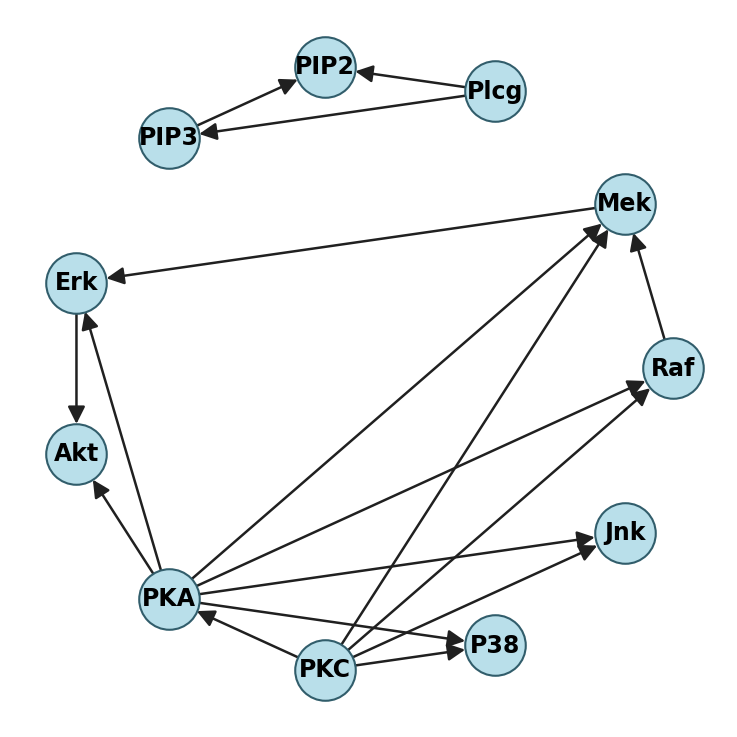

Original: /home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_true.pdf


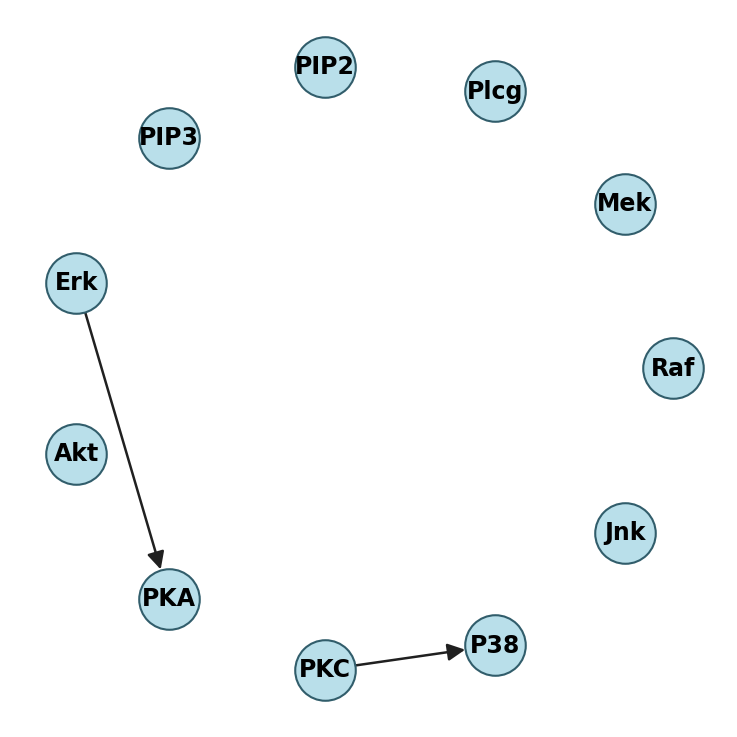

DAGMA: /home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_est_DAGMA.pdf


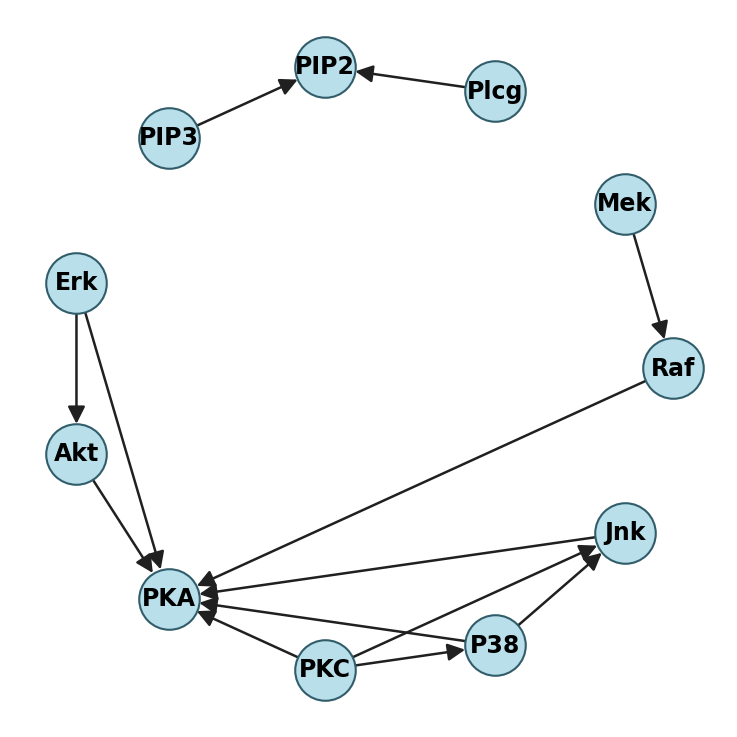

CoLiDE-NV: /home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_est_CoLiDE_NV.pdf


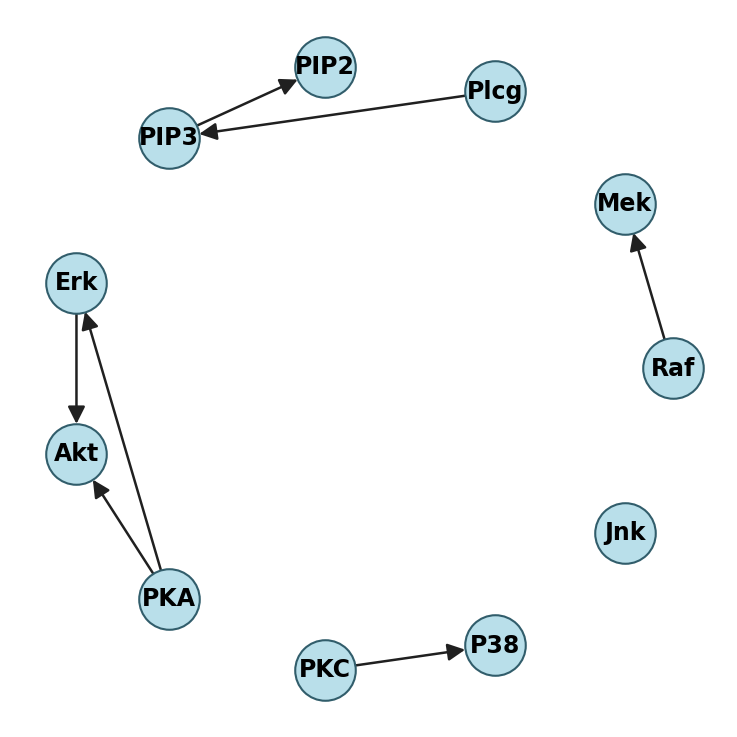

NOMAD-adam: /home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_est_NOMAD_adam.pdf


{'Original': PosixPath('/home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_true.pdf'),
 'DAGMA': PosixPath('/home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_est_DAGMA.pdf'),
 'CoLiDE-NV': PosixPath('/home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_est_CoLiDE_NV.pdf'),
 'NOMAD-adam': PosixPath('/home/srey/Investigacion/cvx_dag_learning/results/sachs/imgs/G_est_NOMAD_adam.pdf')}

In [43]:
# Export a selected subset of unscaled graph estimates as separate PDF panels.
GRAPH_OUTPUT_DIR = ROOT / 'results' / 'sachs' / 'imgs'

graph_subset = ['Original', 'DAGMA', 'CoLiDE-NV', 'NOMAD-adam']
saved_graph_pdfs = plot_selected_graphs(
    graph_subset, Exps, Ws_est, W, node_order, GRAPH_OUTPUT_DIR,
    default_threshold=.3, thresholds=unscaled_thresholds, show=True,
)
saved_graph_pdfs

In [44]:
def rescale_plot_results(exps, Ws_est, W_true, running_times, thr=.3, plot=False, thresholds=None):
    
    thresholds = {} if thresholds is None else thresholds
    norm_W_true = np.linalg.norm(W_true)
    rows = []

    for i, exp in enumerate(exps):
        model_thr = thresholds.get(exp['leg'], thr)
        W_true_bin = utils.to_bin(W_true, model_thr)
        W_est = Ws_est[i].copy()

        W_est /= np.max(np.abs(W_est))
        if exp.get('to_dag', False):
            W_est = utils.to_dag(W_est, model_thr)

        W_est_bin = utils.to_bin(W_est, model_thr)
        shd, tpr, fdr = utils.count_accuracy(W_true_bin, W_est_bin)
        fscore = f1_score(W_true_bin.flatten(), W_est_bin.flatten())
        err = utils.compute_norm_sq_err(W_true, W_est, norm_W_true)
        sid = utils.sid(W_true_bin, W_est_bin, normalize=True) if utils.is_dag(W_est_bin) else np.nan
        rows.append({
            'Method': exp['leg'],
            'Standardized': exp.get('standarize', False),
            'Threshold': model_thr,
            'SHD': shd,
            'TPR': tpr,
            'FDR': fdr,
            'F1': fscore,
            'SID': sid,
            'Error': err,
            'Time (s)': running_times[i],
        })

        if plot:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            im1 = ax1.imshow(W_true, cmap='Blues', interpolation='none')
            ax1.set_title("W true")
            fig.colorbar(im1, ax=ax1)
            im2 = ax2.imshow(W_est, cmap='Blues', interpolation='none')
            ax2.set_title("W_est - " + exp['leg'])
            fig.colorbar(im2, ax=ax2)

    results = pd.DataFrame(rows)
    used_thresholds = results['Threshold'].unique()
    table_thr = used_thresholds[0] if len(used_thresholds) == 1 else None
    caption = 'Rescaled results' if table_thr is not None else 'Rescaled results · per-model thresholds'
    display_results_table(results, table_thr, caption=caption)
    return results

# Every experiment omitted here uses the default threshold (.3).
rescaled_thresholds = {
    'NOMAD-fista': .1,
    'NoTears': .1,
    'NoFears': .1,
    'DAGMA-std': .1,
    'NonDAGMA': .1,
    'CoLiDE-EV': .1,
    'CoLiDE-NV': .1,
    'GOLEM-EV': .1,
    'GOLEM-EV-std': .1,
    'GOLEM-NV-std': .1,
    'SortNReg': .1,
}

rescale_plot_results(
    Exps, Ws_est, W, running_times,
    thr=.3, plot=False, thresholds=rescaled_thresholds,
)

,Method,Standardized,Threshold,SHD,TPR,FDR,F1,SID,Error,Time (s)
0,NOMAD-adam,True,0.30,10,0.412,0.000,0.583,1.545,0.729,2.35
1,NOMAD-fista,False,0.10,13,0.353,0.400,0.444,1.818,1.181,5.88
2,DAGMA,False,0.30,16,0.059,0.500,0.105,2.000,1.645,7.94
3,DAGMA-std,True,0.10,13,0.235,0.333,0.348,2.000,1.620,3.62
4,NonDAGMA,False,0.10,14,0.176,0.500,0.261,2.182,1.435,9.65
5,CoLiDE-EV,False,0.10,13,0.235,0.429,0.333,2.000,1.932,35.54
6,CoLiDE-NV,False,0.10,14,0.176,0.500,0.261,2.091,1.950,20.56
7,GOLEM-EV,False,0.10,17,0.118,0.714,0.167,2.636,1.841,120.10
8,GOLEM-EV-std,True,0.10,17,0.176,0.667,0.231,3.636,1.843,80.28
9,GOLEM-NV,False,0.30,15,0.118,0.600,0.182,2.273,1.586,146.04


,Method,Standardized,Threshold,SHD,TPR,FDR,F1,SID,Error,Time (s)
0,NOMAD-adam,True,0.3,10,0.411765,0.000000,0.583333,1.545455,0.728862,2.348458
1,NOMAD-fista,False,0.1,13,0.352941,0.400000,0.444444,1.818182,1.181358,5.877169
2,DAGMA,False,0.3,16,0.058824,0.500000,0.105263,2.000000,1.645077,7.939248
3,DAGMA-std,True,0.1,13,0.235294,0.333333,0.347826,2.000000,1.620279,3.617572
4,NonDAGMA,False,0.1,14,0.176471,0.500000,0.260870,2.181818,1.435141,9.645149
5,CoLiDE-EV,False,0.1,13,0.235294,0.428571,0.333333,2.000000,1.932169,35.535554
6,CoLiDE-NV,False,0.1,14,0.176471,0.500000,0.260870,2.090909,1.950212,20.555504
7,GOLEM-EV,False,0.1,17,0.117647,0.714286,0.166667,2.636364,1.840530,120.099553
8,GOLEM-EV-std,True,0.1,17,0.176471,0.666667,0.230769,3.636364,1.842622,80.276475
9,GOLEM-NV,False,0.3,15,0.117647,0.600000,0.181818,2.272727,1.585943,146.041945


In [45]:
# Optional comparison with one common threshold for every model:
# rescale_plot_results(Exps, Ws_est, W, running_times, thr=.1, plot=False)